# Partie D — Modélisation : estimation du prix des voitures d'occasion

**Périmètre :** Ce notebook couvre la **modélisation** (mon rôle dans le projet d'équipe).
Il consomme les données issues de l'étape de préparation et construit, compare et
optimise plusieurs modèles de régression pour prédire le prix (en MAD).

**Hypothèse d'entrée :** les données ont passé une validation de cohérence (valeurs
de prix et de kilométrage physiquement impossibles écartées). La logique de nettoyage
complète appartient à l'étape *preprocessing* ; ce notebook applique une revérification
défensive mais n'en est pas propriétaire.

**Démarche :**
1. Audit rapide des données → 2. Split train/test (stratifié, cible log) →
3. Pipeline anti-fuite (preprocessing dans la CV) → 4. Baseline 5 modèles →
5. Sélection de features → 6. Tuning → 7. Évaluation finale sur test.

**Pour exécuter :** installer `requirements.txt`, puis « Restart & Run All ». Le tuning
(section 6) prend quelques minutes. Le modèle ajusté est disponible en fin de notebook
(`best_model`) et sauvegardé dans `models/`.

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

## 1. Audit des données et nettoyage

Avant toute modélisation, on inspecte les données brutes pour repérer les problèmes
qui fausseraient les modèles : types incorrects, valeurs manquantes, et surtout
**valeurs aberrantes** (prix ou kilométrages physiquement impossibles issus du scraping).

La fonction `load_clean_data()` applique un nettoyage **déterministe** (aucun paramètre
appris sur les données) : parsing du kilométrage, mise au format des valeurs manquantes,
filtrage des valeurs hors-bornes, et création de deux features (`age_voiture`, `km_par_an`).
Étant déterministe, ce nettoyage ne provoque aucune fuite de données.

In [57]:
import pandas as pd, numpy as np
df = pd.read_csv("../data/raw_moteur.csv")

print("=== dtypes ===")
print(df.dtypes)

print("\n=== missing prix ===", df['prix'].isna().sum())

print("\n=== missingness % (N/A unmasked) ===")
dfc = df.replace(['N/A','n/a',''], np.nan)
print((dfc.isna().mean()*100).round(1).sort_values(ascending=False))

print("\n=== Kilométrage format check: any value NOT matching '<digits> km'? ===")
mask = ~df['Kilométrage'].astype(str).str.match(r'^[\d,]+\s*km$', na=False)
print("non-conforming count:", mask.sum())
print(df.loc[mask, 'Kilométrage'].head(20).tolist())

print("\n=== Année: dtype, range, weird values ===")
print(df['Année'].describe())
print("year >= 2025:", (df['Année'] >= 2025).sum(), "| year < 1990:", (df['Année'] < 1990).sum())

print("\n=== Cylindrée: how empty, and what do non-empty look like? ===")
print("missing %:", (df['Cylindrée'].isna().mean()*100).round(1))
print(df['Cylindrée'].dropna().head(10).tolist())

=== dtypes ===
Lien_index               int64
Marque                  object
Modèle                  object
Année                  float64
Kilométrage             object
Carburant               object
Transmission            object
Carrosserie             object
Couleur                 object
Puissance fiscale      float64
Nombre de portes       float64
prix                   float64
ville                   object
État du véhicule         int64
Airbags                  int64
Navigation GPS           int64
Ordinateur de bord       int64
Limiteur de vitesse      int64
Climatisation            int64
Intérieur cuir           int64
Radar de recul           int64
Cylindrée              float64
dtype: object

=== missing prix === 1218

=== missingness % (N/A unmasked) ===
Cylindrée              100.0
Carrosserie             59.4
Couleur                 43.9
Nombre de portes        30.1
Puissance fiscale       22.8
prix                    14.9
ville                    8.4
Transmission         

**Constats de l'audit :**
- `Kilométrage` est au format texte (`"107,000 km"`) → à parser en numérique.
- `prix` comporte des valeurs manquantes → ces lignes seront supprimées (on n'impute jamais la cible).
- `Cylindrée` ~100 % manquante, `Carrosserie` ~59 %, `Couleur` ~44 % → colonnes écartées.
- `Année` contient des valeurs aberrantes (0, années > 2024) → à filtrer / borner.
- Cardinalité élevée de `Marque`, `Modèle`, `ville` → encodage par cible plutôt que one-hot.

In [58]:
import pandas as pd, numpy as np

def load_clean_data(path="../data/raw_moteur.csv", current_year=2026):
    df = pd.read_csv(path)

    # --- price integrity: drop missing prices AND physically impossible values ---
    # NaN prices fail the >= comparison, so this also removes no-price rows.
    # Bounds 5k–2M MAD remove scrape artifacts (1-dirham and 58M-dirham listings).
    df = df[(df['prix'] >= 5_000) & (df['prix'] <= 2_000_000)].copy()

    # --- unmask fake-missing values: literal "N/A" and blank strings -> real NaN ---
    df = df.replace(['N/A', 'n/a', ''], np.nan)

    # --- parse Kilométrage: "107,000 km" -> 107000.0 ---
    # strip unit + thousands separator; the few non-numeric entries become NaN.
    df['Kilométrage'] = (df['Kilométrage'].astype(str)
                         .str.replace('km', '', regex=False)
                         .str.replace(',', '', regex=False)
                         .str.strip()
                         .replace('nan', np.nan)
                         .astype(float))

    # --- mileage ceiling: cap at 600k km (99.9th pct jumps to millions = noise) ---
    df = df[df['Kilométrage'] <= 600_000].copy()

    # --- year sanity: drop Année=0 and pre-1990 listings (scrape noise) ---
    df = df[df['Année'] >= 1990].copy()

    # --- feature engineering (row-wise, no learned parameters -> leakage-free) ---
    # age clipped at 0 so new-car listings (2025/2026) get age 0 rather than negative.
    df['age_voiture'] = (current_year - df['Année']).clip(lower=0)
    # km == 0 is only legitimate for new cars; otherwise it's a missing value coded as 0.
    df.loc[(df['Kilométrage'] == 0) & (df['age_voiture'] > 0), 'Kilométrage'] = np.nan
    # km/year; guard against division by zero for age-0 cars (-> NaN, imputed later).
    df['km_par_an'] = df['Kilométrage'] / df['age_voiture'].replace(0, np.nan)

    # --- drop unusable columns ---
    # Cylindrée ~100% missing | Carrosserie ~59% | Couleur ~44% | Lien_index = scrape id
    df = df.drop(columns=['Cylindrée', 'Carrosserie', 'Couleur', 'Lien_index'])

    return df

### Pourquoi ces filtres de cohérence ?

Un premier passage de modélisation sur données non filtrées plafonnait **tous** les
modèles à R² ≈ 0,38 — les modèles d'ensemble (Random Forest, XGBoost) ne faisaient
pas mieux qu'une régression linéaire, signal classique d'un bruit qui noie l'information.

Le diagnostic (voir plus bas) a révélé des valeurs **physiquement impossibles** issues
du scraping : un kilométrage maximal de ~2,1 milliards de km et un prix maximal de
58 M MAD. Après filtrage de ces aberrations, les performances passent à R² ≈ 0,78.

`load_clean_data` ci-dessous intègre cette validation de bornes (déterministe, donc
sans fuite de données).

In [59]:
df = load_clean_data()

# --- confirm the clean did what we intended ---
print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("\nprix range (MAD):", df['prix'].min(), "..", df['prix'].max())   # bounded 5k–2M
print("Kilométrage max:", df['Kilométrage'].max())                       # <= 600k
print("km==0 with age>0:", ((df['Kilométrage'] == 0) & (df['age_voiture'] > 0)).sum())  # must be 0
print("dropped cols absent:",
      all(c not in df.columns for c in ['Cylindrée', 'Carrosserie', 'Couleur', 'Lien_index']))
print("\n", df['Kilométrage'].describe())   # std should be ~80k, not millions
df.head()

shape: (6763, 20)
columns: ['Marque', 'Modèle', 'Année', 'Kilométrage', 'Carburant', 'Transmission', 'Puissance fiscale', 'Nombre de portes', 'prix', 'ville', 'État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an']

prix range (MAD): 5000.0 .. 2000000.0
Kilométrage max: 600000.0
km==0 with age>0: 0
dropped cols absent: True

 count      6609.000000
mean     118333.218793
std       81255.305871
min           0.000000
25%       59559.000000
50%      105000.000000
75%      162000.000000
max      600000.000000
Name: Kilométrage, dtype: float64


,Marque,Modèle,Année,Kilométrage,Carburant,Transmission,Puissance fiscale,Nombre de portes,prix,ville,État du véhicule,Airbags,Navigation GPS,Ordinateur de bord,Limiteur de vitesse,Climatisation,Intérieur cuir,Radar de recul,age_voiture,km_par_an
0,Skoda,Superb,2019.0,107000.0,Diesel,Automatique,NaN,NaN,198000.0,Casablanca,1,0,0,0,0,0,0,0,7.0,15285.714286
1,Nissan,Qashqai,2013.0,178000.0,Diesel,Manuelle,7.0,4.0,160000.0,NaN,0,0,0,0,0,0,0,0,13.0,13692.307692
2,Volkswagen,Golf 5,2007.0,249000.0,Diesel,Manuelle,8.0,5.0,81000.0,Casablanca,0,1,1,0,0,1,0,0,19.0,13105.263158
3,Peugeot,2008,2014.0,168000.0,Diesel,Manuelle,6.0,NaN,120000.0,Tanger,0,0,0,0,0,0,0,0,12.0,14000.000000
4,Citroën,C5,2019.0,129000.0,Diesel,Automatique,8.0,3.0,200000.0,Casablanca,0,0,0,0,0,0,0,0,7.0,18428.571429


**Vérification du nettoyage** — on confirme que les bornes sont respectées, que la
règle « km=0 uniquement pour voitures neuves » a fonctionné, et que l'écart-type du
kilométrage est revenu à un ordre de grandeur réaliste (~80k au lieu de millions).

## 2. Séparation train / test

Trois choix méthodologiques ici, tous destinés à obtenir une évaluation **honnête** :

- **Cible en log (`log1p`)** : les prix sont fortement asymétriques (quelques voitures
  de luxe écrasent la distribution). Modéliser `log(prix)` stabilise la variance et
  évite que les erreurs sur les voitures chères dominent l'apprentissage. Les métriques
  finales seront re-transformées en MAD via `expm1`.

- **Split stratifié sur des tranches de prix** : un découpage purement aléatoire pourrait
  concentrer les voitures chères dans train ou test. On stratifie sur 5 quantiles de prix
  (`pd.qcut`) pour que train et test aient des distributions de prix comparables.
  *Note : on stratifie sur des tranches, jamais sur la cible continue elle-même.*

- **Le split AVANT tout preprocessing appris** : l'imputation, le scaling et l'encodage
  par cible apprennent des paramètres sur les données. S'ils voyaient le test, ses
  statistiques fuiteraient dans l'entraînement. Le test est mis de côté ici et n'est
  touché qu'à l'étape finale d'évaluation.

In [60]:
from sklearn.model_selection import train_test_split

y = np.log1p(df['prix'])           # log-target; back-transformed with expm1 at evaluation
X = df.drop(columns=['prix'])

price_bins = pd.qcut(df['prix'], q=5, labels=False)   # 5 quantile bins for stratification

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=price_bins,
)

print("train:", X_train.shape, "| test:", X_test.shape)
# medians should be close → stratification gave train/test matching price distributions
print("train price median:", np.expm1(y_train).median().round(0),
      "| test  price median:", np.expm1(y_test).median().round(0))

train: (5410, 19) | test: (1353, 19)
train price median: 200000.0 | test  price median: 200000.0


## 3. Pipeline de preprocessing anti-fuite

Le cœur méthodologique du notebook. Contrairement à un nettoyage déterministe
(section 1), les transformations ci-dessous **apprennent des paramètres** sur les
données : la médiane d'imputation, la moyenne/écart-type du scaling, et surtout
l'encodage par cible (`TargetEncoder`) qui apprend la relation marque→prix.

Ces transformations sont encapsulées dans un `ColumnTransformer` placé **à l'intérieur**
du pipeline. Conséquence : lors de la validation croisée, elles sont ré-apprises sur
la portion d'entraînement de **chaque fold** uniquement — jamais sur les données de
validation. C'est ce qui garantit l'absence de fuite.

Traitement par type de colonne :
| Colonnes | Traitement | Raison |
|----------|-----------|--------|
| Numériques | médiane → StandardScaler | scaling utile aux modèles linéaires ; sans effet (mais inoffensif) sur les arbres |
| `Marque`, `Modèle`, `ville` (forte cardinalité) | TargetEncoder | le one-hot exploserait la dimension ; l'encodage par cible reste compact |
| `Carburant`, `Transmission` (faible cardinalité) | mode → OneHot | peu de modalités, one-hot adapté |
| Options binaires (0/1) | passthrough | déjà au bon format |

*`Année` et `age_voiture` sont colinéaires (age = 2026 − Année) : sans effet sur les
arbres, et la régularisation L2 de Ridge l'absorbe côté linéaire.*

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder

numeric_cols   = ['Année', 'Kilométrage', 'Puissance fiscale',
                  'Nombre de portes', 'age_voiture', 'km_par_an']
highcard_cols  = ['Marque', 'Modèle', 'ville']
lowcard_cols   = ['Carburant', 'Transmission']
binary_cols    = ['État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord',
                  'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul']

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

highcard_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', TargetEncoder(random_state=42)),   # fold-fit → no leakage
])

lowcard_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num',  numeric_pipe,  numeric_cols),
    ('high', highcard_pipe, highcard_cols),
    ('low',  lowcard_pipe,  lowcard_cols),
    ('bin',  'passthrough',  binary_cols),
], remainder='drop')   # anything unlisted is dropped (safety)

In [62]:
# === DIAGNOSTIC (evidence): the R² jump from removing impossible values ===
# Self-contained & rerun-safe: builds a MINIMAL clean WITHOUT the range filters,
# then WITH them, and compares one quick model. Shows why the filters matter.

def _minimal_clean(filter_ranges):
    d = pd.read_csv("../data/raw_moteur.csv")
    d = d[d['prix'].notna()].copy()
    d['Kilométrage'] = (d['Kilométrage'].astype(str)
        .str.replace('km','',regex=False).str.replace(',','',regex=False)
        .str.strip().replace('nan', np.nan).astype(float))
    d = d[d['Année'] >= 1990].copy()
    if filter_ranges:                                   # the ONLY difference
        d = d[(d['prix'] >= 5_000) & (d['prix'] <= 2_000_000)]
        d = d[d['Kilométrage'] <= 600_000]
    d['age_voiture'] = (2026 - d['Année']).clip(lower=0)
    d['km_par_an'] = d['Kilométrage'] / d['age_voiture'].replace(0, np.nan)
    return d.drop(columns=['Cylindrée','Carrosserie','Couleur','Lien_index'])

for label, flag in [("SANS filtres de bornes", False), ("AVEC filtres de bornes", True)]:
    d = _minimal_clean(flag)
    yq = np.log1p(d['prix']); Xq = d.drop(columns=['prix'])
    quick = Pipeline([('prep', preprocessor),
                      ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
    r2 = cross_val_score(quick, Xq, yq, cv=3, scoring='r2', n_jobs=-1).mean()
    print(f"{label:25s} → R² = {r2:.3f}")

SANS filtres de bornes    → R² = 0.350
AVEC filtres de bornes    → R² = 0.768


**Preuve chiffrée des filtres de la section 1** — on compare un modèle rapide (Random
Forest, 3-fold) entraîné sur les données *sans* puis *avec* les filtres de bornes.
L'écart de R² illustre pourquoi ces filtres étaient indispensables : sans eux, les
valeurs aberrantes (kilométrage en milliards, prix en dizaines de millions — voir
section 1) noient le signal. Les chiffres ci-dessous sont *illustratifs* (un seul
modèle, 3-fold) et ne correspondent pas exactement au baseline complet de la section 4.

## 4. Modèles : baseline et validation croisée

On compare cinq régressions sur des features **identiques**, chacune en validation
croisée 5-fold. La cible étant continue, on utilise `KFold`.

In [65]:
cv = KFold(n_splits=5, shuffle=True, random_state=42) 
models = {
    'LinearRegression': LinearRegression(),
    'Ridge':            Ridge(random_state=42),
    'RandomForest':     RandomForestRegressor(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
    'XGBoost':          XGBRegressor(random_state=42, n_jobs=-1),
}

pipelines = {
    name: Pipeline([('prep', preprocessor), ('model', est)])
    for name, est in models.items()
}

In [66]:
results = {}
for name, pipe in pipelines.items():
    rmse = -cross_val_score(pipe, X_train, y_train, cv=cv,
                            scoring='neg_root_mean_squared_error', n_jobs=-1)
    r2   =  cross_val_score(pipe, X_train, y_train, cv=cv,
                            scoring='r2', n_jobs=-1)
    results[name] = {'rmse_log_mean': rmse.mean(), 'rmse_log_std': rmse.std(),
                     'r2_mean': r2.mean(), 'r2_std': r2.std()}
    print(f"{name:18s} RMSE(log)={rmse.mean():.4f}±{rmse.std():.4f}  R²={r2.mean():.4f}±{r2.std():.4f}")

import pandas as pd
results_df = pd.DataFrame(results).T.sort_values('r2_mean', ascending=False)

LinearRegression   RMSE(log)=0.3341±0.0258  R²=0.7348±0.0250
Ridge              RMSE(log)=0.3341±0.0260  R²=0.7349±0.0253
RandomForest       RMSE(log)=0.3067±0.0254  R²=0.7762±0.0253
GradientBoosting   RMSE(log)=0.3072±0.0281  R²=0.7756±0.0274
XGBoost            RMSE(log)=0.3137±0.0221  R²=0.7661±0.0201


| Modèle | R² (CV) | RMSE (log) | Lecture |
|--------|---------|-----------|---------|
| RandomForest | 0.776 | 0.307 | meilleurs modèles d'ensemble |
| GradientBoosting | 0.776 | 0.307 | |
| XGBoost | 0.766 | 0.314 | |
| Ridge | 0.735 | 0.334 | base linéaire solide |
| LinearRegression | 0.735 | 0.334 | |

## 5. Sélection de features (RFE)

On teste si réduire le nombre de features améliore le modèle linéaire. La RFE
(Recursive Feature Elimination) élimine itérativement les features les moins
importantes selon les coefficients de Ridge.

**Pourquoi seulement sur le modèle linéaire ?** Les modèles d'arbres font déjà une
sélection implicite (ils ignorent les features non informatives lors des splits).
Les envelopper dans une RFE coûterait des centaines de ré-entraînements pour un gain
nul. La RFE a du sens sur Ridge, sensible aux features redondantes.

In [67]:
from sklearn.feature_selection import RFE

ridge_rfe = Pipeline([
    ('prep', preprocessor),
    ('select', RFE(estimator=Ridge(random_state=42), n_features_to_select=10, step=1)),
    ('model', Ridge(random_state=42)),
])
r2 = cross_val_score(ridge_rfe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)
print(f"Ridge + RFE  R²={r2.mean():.4f}±{r2.std():.4f}")

Ridge + RFE  R²=0.7273±0.0206


**Résultat : la sélection de features n'améliore pas le modèle.**

Ridge + RFE (10 features) : R² ≈ **0.727**, contre **0.735** pour Ridge avec toutes
les features. Réduire le nombre de features a donc *légèrement dégradé* la performance.

C'est un résultat informatif, pas un échec : il indique que **toutes les features
portent de l'information** — aucune n'est redondante au point de nuire. On conserve
donc l'ensemble complet des features pour la suite.

*Principe : on privilégie le modèle le plus simple à performance égale ou supérieure.
Ici, « toutes les features » est à la fois plus simple (pas d'étape de sélection) et
plus performant — le choix est clair.*

## 6. Optimisation des hyperparamètres

Les trois modèles d'arbres étant trop proches au baseline (~0.01 d'écart), on les
optimise pour les départager. On utilise `RandomizedSearchCV` (25 combinaisons
aléatoires par modèle) plutôt qu'une grille exhaustive : sur cet espace de paramètres,
un tirage aléatoire trouve de très bonnes combinaisons pour une fraction du coût de calcul.

Le tuning se fait **dans le pipeline** : à chaque combinaison testée, le preprocessing
(imputation, scaling, encodage par cible) est ré-appris sur chaque fold — la garantie
anti-fuite est maint

In [69]:
from sklearn.model_selection import RandomizedSearchCV

search_spaces = {
    'RandomForest': (RandomForestRegressor(random_state=42, n_jobs=-1), {
        'model__n_estimators': [200, 400, 600],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_leaf': [1, 2, 4],
        'model__max_features': ['sqrt', 0.5, 1.0],
    }),
    'GradientBoosting': (GradientBoostingRegressor(random_state=42), {
        'model__n_estimators': [200, 400],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [2, 3, 4],
        'model__subsample': [0.8, 1.0],
    }),
    'XGBoost': (XGBRegressor(random_state=42, n_jobs=-1), {
        'model__n_estimators': [300, 600],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
    }),
}

tuned = {}
for name, (est, space) in search_spaces.items():
    pipe = Pipeline([('prep', preprocessor), ('model', est)])
    search = RandomizedSearchCV(
        pipe, space, n_iter=25, cv=cv,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1, verbose=0,
    )
    search.fit(X_train, y_train)
    tuned[name] = search

    # R² (CV) of the tuned pipeline, on the same folds — for an interpretable second metric
    r2 = cross_val_score(search.best_estimator_, X_train, y_train,
                         cv=cv, scoring='r2', n_jobs=-1).mean()
    print(f"{name:18s} RMSE(log)={-search.best_score_:.4f}  R²(CV)={r2:.4f}")
    print(f"   params: {search.best_params_}")

RandomForest       RMSE(log)=0.2982  R²(CV)=0.7886
   params: {'model__n_estimators': 600, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 30}
GradientBoosting   RMSE(log)=0.3014  R²(CV)=0.7842
   params: {'model__subsample': 0.8, 'model__n_estimators': 200, 'model__max_depth': 4, 'model__learning_rate': 0.05}
XGBoost            RMSE(log)=0.2952  R²(CV)=0.7930
   params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


**Résultats du tuning :**

| Modèle | RMSE (log) baseline | RMSE (log) tuned | R² (CV) tuned |
|--------|---------------------|------------------|---------------|
| **XGBoost** | 0.314 | **0.295** | **~0.793** |
| RandomForest | 0.307 | 0.298 | ~0.788 |
| GradientBoosting | 0.307 | 0.301 | ~0.784 |

Observation clé : **XGBoost, troisième au baseline, devient le meilleur après tuning.**
C'est précisément la raison pour laquelle on optimise avant de choisir — le classement
non-optimisé n'aurait pas désigné le bon modèle. Les trois restent proches, mais
XGBoost a la meilleure RMSE en validation croisée.

**Modèle retenu : XGBoost.** Ses paramètres optimaux (profondeur modérée, taux
d'apprentissage faible, sous-échantillonnage des lignes et colonnes) traduisent un
modèle bien régularisé — ce qui annonce une bonne généralisation sur le test.

## 7. Évaluation finale sur le test

C'est le **seul** moment où l'on touche l'ensemble de test, mis de côté depuis le split
et jamais vu par aucune transformation apprise. Le modèle retenu (XGBoost optimisé) y
est évalué **une seule fois** — l'évaluer sur plusieurs modèles pour choisir le meilleur
reviendrait à régler le modèle sur le test et fausserait l'estimation de généralisation.

Les métriques sont re-transformées en dirhams (`expm1`) pour être interprétables :
- **MAE** : erreur absolue moyenne — « de combien on se trompe en moyenne, en MAD ».
- **RMSE** : pénalise davantage les grosses erreurs (voitures de luxe).
- **R²** : part de la variance du prix expliquée.

In [70]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

best_model = tuned['XGBoost'].best_estimator_   # already fitted on full X_train

# predict on held-out test (log space) → back-transform to MAD
y_pred_log = best_model.predict(X_test)
y_pred_mad = np.expm1(y_pred_log)
y_true_mad = np.expm1(y_test)

# honest metrics in real dirhams
rmse = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
mae  = mean_absolute_error(y_true_mad, y_pred_mad)
r2   = r2_score(y_true_mad, y_pred_mad)

print(f"Test R²   : {r2:.4f}")
print(f"Test RMSE : {rmse:,.0f} MAD")
print(f"Test MAE  : {mae:,.0f} MAD")
print(f"Test R² (log space): {r2_score(y_test, y_pred_log):.4f}")

Test R²   : 0.7082
Test RMSE : 106,287 MAD
Test MAE  : 43,765 MAD
Test R² (log space): 0.7800


**Lecture des résultats sur le test :**

| Métrique | Valeur | Interprétation |
|----------|--------|----------------|
| R² (log) | 0.78 | cohérent avec la CV (~0.78) → **pas de surapprentissage** |
| R² (MAD) | 0.71 | part de variance expliquée en dirhams réels |
| MAE | ~43 800 MAD | erreur typique sur une voiture |
| RMSE | ~106 300 MAD | erreur quadratique, sensible aux grosses erreurs |

Trois enseignements :

- **Le R² test (0.78) colle au R² de validation croisée** : le modèle généralise, il
  n'a pas mémorisé les données d'entraînement. Les hyperparamètres régularisés (tuning)
  ont tenu leur promesse.
- **RMSE ≫ MAE** (106k vs 44k) : une minorité de voitures concentre les grosses erreurs.
  Ce sont les véhicules chers — la transformation `expm1` amplifie l'erreur sur les grands
  prix, et il y a moins d'exemples haut de gamme pour apprendre.
- **R² en MAD (0.71) < R² en log (0.78)** : même cause — l'erreur sur la longue traîne
  des prix élevés pèse davantage en dirhams qu'en échelle log.

**Limite du modèle (honnête) :** il est fiable sur le marché grand public (le gros du
volume) et moins précis sur les voitures rares et chères, faute de signal d'apprentissage
suffisant dans cette tranche.

**Diagnostics du modèle retenu.** Deux graphiques valident le comportement de XGBoost
sur le test (il s'agit de *diagnostics de performance*, non d'interprétation du modèle —
l'attribution détaillée des features relève du notebook d'interprétabilité) :

- **Prédit vs Réel** : les points doivent s'aligner sur la diagonale. Un resserrement
  aux prix bas/moyens et un évasement aux prix élevés confirmeraient la faiblesse sur la
  traîne haut de gamme.
- **Résidus** : dispersés autour de 0 sans structure = bon signe ; un évasement aux prix
  élevés traduit l'erreur plus forte sur les voitures chères.

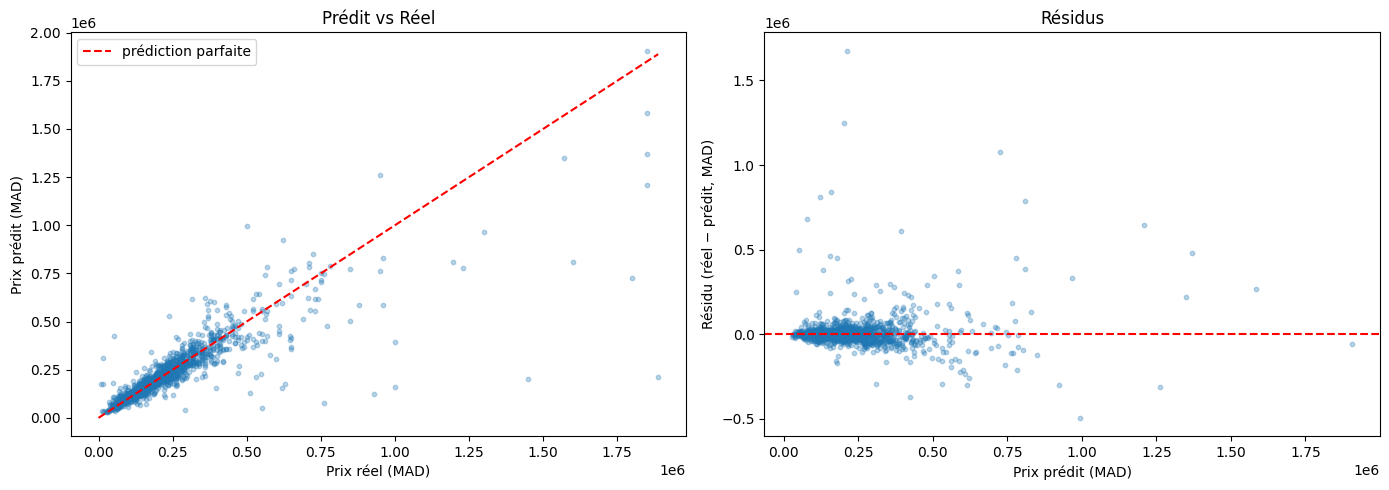

In [72]:
import matplotlib.pyplot as plt
import os
os.makedirs("../reports", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Predicted vs Actual (in MAD) ---
axes[0].scatter(y_true_mad, y_pred_mad, alpha=0.3, s=10)
lims = [0, y_true_mad.max()]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='prédiction parfaite')
axes[0].set_xlabel("Prix réel (MAD)")
axes[0].set_ylabel("Prix prédit (MAD)")
axes[0].set_title("Prédit vs Réel")
axes[0].legend()

# --- 2. Residuals vs Predicted (in MAD) ---
residuals = y_true_mad - y_pred_mad
axes[1].scatter(y_pred_mad, residuals, alpha=0.3, s=10)
axes[1].axhline(0, color='r', ls='--', lw=1.5)
axes[1].set_xlabel("Prix prédit (MAD)")
axes[1].set_ylabel("Résidu (réel − prédit, MAD)")
axes[1].set_title("Résidus")

plt.tight_layout()
plt.savefig("../reports/xgboost_evaluation.png", dpi=120, bbox_inches='tight')  # for the README
plt.show()

## 8. Sauvegarde du modèle

On sérialise le **pipeline complet** (preprocessing + modèle), pas seulement XGBoost :
il contient les transformations *ajustées* (imputation, scaling, encodage par cible),
donc `joblib.load(...).predict(X)` fonctionne de bout en bout sur des données au format
de `load_clean_data()`.

Conformément au `.gitignore` du projet, `models/` n'est pas suivi par git (artefact
régénérable en relançant le notebook).

In [73]:
import joblib, os
os.makedirs("../models", exist_ok=True)
best_model = tuned['XGBoost'].best_estimator_   # full pipeline: preprocessing + model
joblib.dump(best_model, "../models/xgboost_pipeline.joblib")
print("Saved:", round(os.path.getsize("../models/xgboost_pipeline.joblib")/1024, 1), "KB")

Saved: 747.6 KB
